In [101]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

In [102]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [103]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/add-memory",
    "https://docs.langchain.com/oss/python/langgraph/quickstart"
]

In [104]:
docs = [WebBaseLoader(url).load() for url in urls]

docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallC

In [105]:
doc_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
docs_splits = text_splitter.split_documents(doc_list)

print(docs_splits)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCo

In [106]:
#Addall texts to VectorDB

vectorstore = FAISS.from_documents(
    documents=docs_splits,
    embedding=HuggingFaceEmbeddings()
)

retriever = vectorstore.as_retriever()

In [107]:
#Adding retriever to retriever tools

from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="retriever_vector_db_blog",
    description="Search and Run information about LangGraph"
)

retriever_tool


StructuredTool(name='retriever_vector_db_blog', description='Search and Run information about LangGraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x370123b50>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x370123eb0>)

In [108]:
#Langchain Blogs  - Separate VectorDB

langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/agents",
    "https://docs.langchain.com/oss/python/langchain/models"
]

In [109]:
langchain_docs = [WebBaseLoader(url).load() for url in langchain_urls]

langchain_docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel 

In [110]:
langchain_docs_list = [item for sublist in langchain_docs for item in sublist]

In [111]:
langchain_docs_list

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel C

In [112]:
langchain_docs_splits = text_splitter.split_documents(langchain_docs_list)

langchain_docs_splits

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel C

In [113]:
vectorstore_langchain = FAISS.from_documents(
    documents=langchain_docs_splits,
    embedding=HuggingFaceEmbeddings()
    
)

In [114]:
retriever_langchain = vectorstore_langchain.as_retriever()

retriever_tool_langchain = create_retriever_tool(
    retriever_langchain,
    name="retriever_langchain",
    description="retriever_vector_langchain_blog",
)

In [115]:
tools = [retriever_tool, retriever_tool_langchain]

## LANGGRAPH WORKFLOW

In [116]:
from typing import Annotated, Sequence, Literal
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

In [117]:
class AgentState(TypedDict):
    #The add messages function defines how an update should be processed
    #Default is to replace add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [118]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x372684a00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x3726ddc00>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [119]:
def agent(state):
    """
    invokes the agent model to generates a response based on the current state. 
    Given the question, it will decide to retrieve using the retriever tool or simply end.

    Arg:
        AgentState(messages): The Current State

    Returns:
        dict: The updated state with agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state['messages']
    model = ChatGroq(model="qwen/qwen3-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)

    #We returns a list, because this will get added to the existing list

    return {"messages":[response]}

In [120]:
from typing import Sequence, Literal, Annotated
from typing_extensions import TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

In [121]:
def grade_documents(state) -> Literal ['generate','rewrite']:
    """ 
    Determines whether the retrieved documents are relevant to the question

    Args:
        state[mesages]: The current state of the graph

    Returns:
        str: A decision for whether the documents are relevant or not.
    """

    print("---CHECK RELEVANCE---")
    ##DATA MODEL
    class grade(BaseModel):
        "Binary score for relevance check"
        binary_score: str = Field(description="Relevance Score: 'yes' or 'no' ")

    ##LLM
    model = ChatGroq(model="qwen/qwen3-32b")
    llm_with_tool = model.with_structured_output(grade)

    ##PROMPT
    prompt = PromptTemplate(
        
        template="""You are a grader assessing relevance of retrieved documents to a user question.\n
                    Here is the retrieved documents:\n\n{context}\n\n
                    Here is the question:\n\n{question}\n
                    if the doument contains the keyword (s) or semantic meaning related to the user question, grade it as relevant\n
                    Give a binary score: 'yes' or 'no' to indicate whether the document is relevant to the question.
        """,
        input_variables=["context","question"]
    )

    #CHAIN
    chain = prompt | llm_with_tool
    messages = state['messages']
    last_message = messages[-1]
    question = messages[0]
    docs = last_message.content

    second_result = chain.invoke({'context':docs, 'question':question})

    score = second_result.binary_score

    if score == 'yes':
        print("---DECISION: DOCUMENTS ARE RELEVANT TO USER QUESTION")
        return 'generate'
    
    else:
        print("---DECISION: DOCUMENTS ARE NOT RELEVANT TO USER QUESTION")
        return "rewrite"


In [122]:
def generate(state):
    """ 
    Generates Answer

    Args:
        state[messages]: The Current State of the Graph

    Returns:
        dict: The updated message
    """

    print("---GENERATE---")
    messages = state['messages']
    question = messages[0].content
    last_messages = messages[-1]

    docs = last_messages.content

    #PROMPT
    prompt = hub.pull('rlm/rag-prompt')

    #LLM
    model = ChatGroq(model="qwen/qwen3-32b")

    #POST PROCESSING
    def format_data(docs):
        return "\n\n".join(doc.page_content for doc in docs)
    
    #CHAIN
    rag_chain = prompt | llm | StrOutputParser()

    #RUN
    response = rag_chain.invoke({"context":docs, "question": question})

    return {"messages": [response]}


In [123]:
def rewrite(state):
    """ 
    Transform the query to produce better response

    ARGS:
        state[messages]: The Current State of the Graph

    Return:
        DICT : the updated state with rephrased question
    """
    print("---TRANSFORM QUERY")
    messages = state['messgaes']
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f"""\n
                    Look at the input and try to reason about the underlying semantic/intent meaning.\n 
                    Here is the initial question:
                    \n --------------------------------------------------------\n
                    {question}
                    \n --------------------------------------------------------\n
                    Formulate an improved question:
            """
        )
    ]

    #GRADER

    model = ChatGroq(model="qwen/qwen3-32b")
    response = model.invoke(msg)

    return {"messages": [response]}

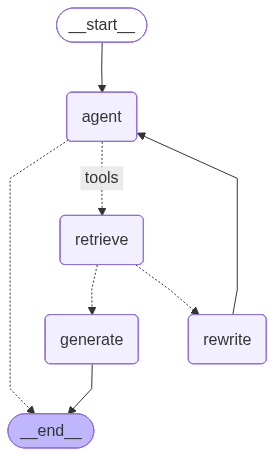

In [124]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#DEFINE A NEW GRAPH
workflow = StateGraph(AgentState)

#DEFINE THE NDOES WE WILL CYCLE BETWEEN
workflow.add_node('agent',agent)
retrieve = ToolNode([retriever_tool, retriever_tool_langchain])
workflow.add_node('retrieve', retrieve)
workflow.add_node('rewrite', rewrite)
workflow.add_node('generate', generate)

#DEFINE THE EDGES
workflow.add_edge(START, 'agent')
workflow.add_conditional_edges(
    'agent',
    #ASSESS AGENT DECISION
    tools_condition,
    {
        #TRANSLATE THE CONDITION OUTPUTS TO NODES IN OUR GRAPH
        'tools':'retrieve',
        END:END
    },
)
workflow.add_conditional_edges(
    'retrieve',
    #ASSESS AGENT DECISION
    grade_documents
)
workflow.add_edge('generate', END)
workflow.add_edge('rewrite', 'agent')

#COMPILE
graph = workflow.compile()

from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [127]:
print(graph.invoke({"messages":"What is LangGraph?"}))

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCUMENTS ARE RELEVANT TO USER QUESTION
---GENERATE---
{'messages': [HumanMessage(content='What is LangGraph?', additional_kwargs={}, response_metadata={}, id='08b8ef4b-c9d7-45a5-9434-05d9a2119d70'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is LangGraph?" I need to figure out which tool to use here. Let me check the available functions. There\'s \'retriever_vector_db_blog\' which is for searching and running information about LangGraph, and \'retriever_langchain\' which is another retriever.\n\nSince the question is specifically about LangGraph, the first function seems more appropriate. The description says it\'s for looking up LangGraph info. So I\'ll use \'retriever_vector_db_blog\' with the query parameter set to "LangGraph". That should fetch the necessary information to answer the user.\n', 'tool_calls': [{'id': 'e3h3qcsqx', 'function': {'arguments': '{"query":"LangGraph"}', 

In [ ]:
response = graph.invoke({"messages":"Who is current Prime Minister of India?"})

print(response)

---CALL AGENT---
{'messages': [HumanMessage(content='Who is current Prime Minister of India?', additional_kwargs={}, response_metadata={}, id='ae08db6b-d697-4e7a-a2fe-26872c33d6a6'), AIMessage(content="I don't have access to real-time data or general knowledge databases to provide the current Prime Minister of India. My capabilities are limited to the specific tools provided, which are focused on LangGraph and LangChain blog searches. Would you like me to help with technical information related to those topics instead?", additional_kwargs={'reasoning_content': "Okay, the user is asking for the current Prime Minister of India. Let me think about the tools I have. There are two functions: one for searching LangGraph information and another for LangChain blog. But the question is about a factual piece of information, the current PM of India. I don't see how either of these tools would help here. The retriever functions are probably for technical blogs related to LangGraph and LangChain, n

In [ ]:
response = graph.invoke({"messages":"Yes"})



---CALL AGENT---


In [131]:
print(response)

{'messages': [HumanMessage(content='Yes', additional_kwargs={}, response_metadata={}, id='dc29d727-4a2e-490e-a2ae-778b688078a0'), AIMessage(content="Hello! It seems like you're agreeing. How can I assist you today? If you have any questions or need information, feel free to ask!", additional_kwargs={'reasoning_content': 'Okay, the user just said "Yes". Let me think about how to respond. They might be agreeing to something, but I need more context. Since the conversation started with them asking about tools, maybe they\'re confirming they want to use one. But there\'s no previous question to reference. Maybe they\'re testing if I\'m listening. I should ask how I can assist them. Let me check the functions available again. The tools are for retrieving info on LangGraph and LangChain. If they need info on those, I can use the functions. But since their response is just "Yes", I need to prompt them further. I\'ll respond by asking what they need help with today.\n'}, response_metadata={'to